# 01 — Data Processing & EDA

Objetivo deste notebook:

1. Sacar/carregar os datasets do Kaggle.
2. Limpar dados de perfis e posts.
3. Criar os targets numéricos `profile_discoverability_score` e `post_discoverability_score`, ambos numa escala **0–100**.
4. Fazer análise exploratória dos dados.
5. Guardar datasets processados para o notebook de feature engineering.

> Nota honesta para o relatório: estes scores são **proxies académicos** de discoverability. Não representam o algoritmo real do LinkedIn.
>
> Correção importante: no target dos posts, o score usa apenas sinais observados de desempenho (`reactions`, `comments`, `followers` e tempo). Características como `media_type`, `num_hashtags`, `hashtags_bin`, `content_length`, `num_links` e `has_media` ficam como features para o modelo tentar aprender, em vez de serem colocadas manualmente na fórmula do target.


In [68]:
# ==============================
# 1. Imports e configuração base
# ==============================

from pathlib import Path
import json
import re
import warnings

import kagglehub
from kagglehub import KaggleDatasetAdapter
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

warnings.filterwarnings("ignore")

# Caminhos do projeto. Os notebooks vivem em /notebooks, por isso usamos "..".
PROJECT_ROOT = Path("..").resolve()
DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
REPORTS_DIR = PROJECT_ROOT / "reports"
FIGURES_DIR = REPORTS_DIR / "figures"

for path in [PROCESSED_DIR, FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)

RANDOM_STATE = 42

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 5)

print("Pastas configuradas:")
print("PROJECT_ROOT:", PROJECT_ROOT)
print("PROCESSED_DIR:", PROCESSED_DIR)


Pastas configuradas:
PROJECT_ROOT: /home/miguellaptop/Secretária/ML
PROCESSED_DIR: /home/miguellaptop/Secretária/ML/data/processed


In [69]:
# ==========================
# 2. Business Understanding
# ==========================

print("Objetivo do projeto")
print("- Criar modelos de regressão que atribuem uma pontuação de 0 a 100 à discoverability de posts e perfis do LinkedIn.")
print("- Perfis: quão descobrível/compatível é um perfil dentro da rede de perfis.")
print("- Posts: quão forte é um post em termos de alcance/engajamento ajustado.")
print("\nLimitação importante")
print("- O target é um proxy académico construído com dados disponíveis. Não é o algoritmo real do LinkedIn.")


Objetivo do projeto
- Criar modelos de regressão que atribuem uma pontuação de 0 a 100 à discoverability de posts e perfis do LinkedIn.
- Perfis: quão descobrível/compatível é um perfil dentro da rede de perfis.
- Posts: quão forte é um post em termos de alcance/engajamento ajustado.

Limitação importante
- O target é um proxy académico construído com dados disponíveis. Não é o algoritmo real do LinkedIn.


In [70]:
# =========================
# 3. Carregamento dos dados
# =========================

# Dataset 1: perfis + pares de compatibilidade
DATASET_PROFILES = "likithagedipudi/linkedin-compatibility-dataset-50k-profiles"

# Dataset 2: posts/influencers
DATASET_POSTS = "shreyasajal/linkedin-influencers-data"

# Carregamento direto para pandas através do kagglehub.
# Caso o Kaggle peça autenticação na tua máquina, instala/configura a API do Kaggle antes de correr.
df_profiles_raw = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    DATASET_PROFILES,
    "profiles.csv",
)

df_pairs_raw = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    DATASET_PROFILES,
    "compatibility_pairs.csv",
)

df_posts_raw = kagglehub.dataset_load(
    KaggleDatasetAdapter.PANDAS,
    DATASET_POSTS,
    "influencers_data.csv",
)

print("Shapes originais:")
print("Perfis:", df_profiles_raw.shape)
print("Pares:", df_pairs_raw.shape)
print("Posts:", df_posts_raw.shape)


Shapes originais:
Perfis: (50000, 20)
Pares: (4999890, 14)
Posts: (34012, 19)


In [71]:
# ============================================
# 4. Helpers robustos de limpeza e normalização
# ============================================

def parse_json_like(value):
    """Converte strings JSON/listas/dicts para objetos Python.

    Porquê?
    - Algumas colunas vêm como texto com listas dentro.
    - Para criar features como num_skills, precisamos de contar elementos sem rebentar com NaN.
    """
    if value is None:
        return []
    if isinstance(value, float) and np.isnan(value):
        return []
    if isinstance(value, (list, dict, tuple, set)):
        return value
    if isinstance(value, str):
        text = value.strip()
        if text in {"", "[]", "{}", "nan", "None"}:
            return []
        try:
            return json.loads(text)
        except Exception:
            # Alguns datasets usam aspas simples; tentamos recuperar.
            try:
                return json.loads(text.replace("'", '"'))
            except Exception:
                return []
    return []


def safe_len(value):
    """Conta elementos de listas/dicts/strings de forma segura."""
    if value is None:
        return 0
    if isinstance(value, float) and np.isnan(value):
        return 0
    if isinstance(value, (list, tuple, set, dict)):
        return len(value)
    if isinstance(value, str):
        return len(parse_json_like(value))
    return 0


def clean_text(value, default=""):
    """Normaliza campos de texto para evitar NaN nos embeddings e contagens."""
    if value is None:
        return default
    if isinstance(value, float) and np.isnan(value):
        return default
    return str(value).strip()


def time_spent_to_days(value):
    """Converte expressões tipo '3 weeks ago' para número de dias.

    Importante: somamos 1 dia no fim para evitar divisão por zero no cálculo do score.
    """
    if value is None:
        return 1
    if isinstance(value, (int, float, np.integer, np.floating)) and not pd.isna(value):
        return max(float(value), 1.0)

    text = str(value).strip().lower()
    if text in {"", "nan", "none", "just now", "now"}:
        return 1

    match = re.match(r"^\s*(\d+)\s+([a-z]+)\s+ago\s*$", text)
    if not match:
        return 1

    qty = int(match.group(1))
    unit = match.group(2)
    factors = {
        "minute": 0, "minutes": 0,
        "hour": 0, "hours": 0,
        "day": 1, "days": 1,
        "week": 7, "weeks": 7,
        "month": 30, "months": 30,
        "year": 365, "years": 365,
    }
    return max(qty * factors.get(unit, 0), 0) + 1


def minmax_0_100(series):
    """Normaliza uma série numérica para a escala 0–100."""
    series = pd.Series(series).astype(float)
    min_value = series.min()
    max_value = series.max()
    if max_value <= min_value:
        return pd.Series(0.0, index=series.index)
    return 100 * (series - min_value) / (max_value - min_value)


In [72]:
# ==============================
# 5. Processamento dos perfis
# ==============================

df_profiles = df_profiles_raw.copy()
df_pairs = df_pairs_raw.copy()

# Remover duplicados por profile_id, porque cada perfil deve ter uma linha única.
df_profiles = df_profiles.drop_duplicates(subset=["profile_id"], keep="first").reset_index(drop=True)

# Parse das colunas estruturadas.
profile_list_cols = ["skills", "experience", "education", "goals", "needs", "can_offer"]
for col in profile_list_cols:
    if col in df_profiles.columns:
        df_profiles[col] = df_profiles[col].apply(parse_json_like)

# Texto limpo.
for col in ["headline", "about", "industry", "seniority_level", "remote_preference"]:
    if col in df_profiles.columns:
        df_profiles[col] = df_profiles[col].apply(lambda x: clean_text(x, default="Unknown"))

# Numéricos principais.
for col in ["connections", "years_experience"]:
    if col in df_profiles.columns:
        df_profiles[col] = pd.to_numeric(df_profiles[col], errors="coerce").fillna(0).clip(lower=0)

# Features simples já no processamento, sem fit estatístico.
df_profiles["num_skills"] = df_profiles.get("skills", pd.Series([], dtype=object)).apply(safe_len)
df_profiles["num_experience"] = df_profiles.get("experience", pd.Series([], dtype=object)).apply(safe_len)
df_profiles["num_education"] = df_profiles.get("education", pd.Series([], dtype=object)).apply(safe_len)
df_profiles["num_goals"] = df_profiles.get("goals", pd.Series([], dtype=object)).apply(safe_len)
df_profiles["num_needs"] = df_profiles.get("needs", pd.Series([], dtype=object)).apply(safe_len)
df_profiles["num_can_offer"] = df_profiles.get("can_offer", pd.Series([], dtype=object)).apply(safe_len)
df_profiles["about_length"] = df_profiles.get("about", "").apply(lambda x: len(clean_text(x)))
df_profiles["headline_length"] = df_profiles.get("headline", "").apply(lambda x: len(clean_text(x)))

# Validar pares de compatibilidade: só queremos pares cujos perfis existem.
df_pairs = df_pairs.drop(columns=["skill_complementarity_score"], errors="ignore")
valid_ids = set(df_profiles["profile_id"])
df_pairs = df_pairs[
    df_pairs["profile_a_id"].isin(valid_ids) & df_pairs["profile_b_id"].isin(valid_ids)
].reset_index(drop=True)

# Target dos perfis: média de compatibilidade recebida por perfil, normalizada 0–100.
avg_compat = (
    df_pairs.groupby("profile_a_id")["compatibility_score"]
    .mean()
    .rename("avg_compatibility_score")
)

df_profiles = df_profiles.merge(
    avg_compat,
    left_on="profile_id",
    right_index=True,
    how="left",
)

df_profiles["avg_compatibility_score"] = df_profiles["avg_compatibility_score"].fillna(0)
df_profiles["profile_discoverability_score"] = minmax_0_100(df_profiles["avg_compatibility_score"])

print("Perfis processados:", df_profiles.shape)
display(df_profiles[["profile_id", "connections", "years_experience", "num_skills", "profile_discoverability_score"]].head())


Perfis processados: (50000, 30)


,profile_id,connections,years_experience,num_skills,profile_discoverability_score
0,ab04b973af478550ddf247879393df42,106,2,5,17.076479
1,b620e3fa2ec361b1d728115eeabb71af,2372,9,15,82.997124
2,cfeeb31581a0b3e0515c01691b9dc2b5,874,5,10,55.019479
3,5d54826665a5898662661a96719cc4a7,3259,17,16,72.570173
4,6ad3c64c6cb4bac60b692f3d5bab271d,372,4,14,42.462239


In [73]:
# ===========================
# 6. Processamento dos posts
# ===========================

df_posts = df_posts_raw.copy()

# Normalizar índice/ID.
rename_map = {
    "Unnamed: 0": "serial_number",
    "unnamed: 0": "serial_number",
    "index": "serial_number",
    "Index": "serial_number",
}
df_posts = df_posts.rename(columns=rename_map)

if "serial_number" in df_posts.columns:
    df_posts = df_posts.set_index("serial_number", verify_integrity=False)

# Remover colunas que podem não estar sempre presentes,
# que duplicam informação ou que não têm variabilidade útil.
# hashtag_followers foi removida porque no dataset está sempre a 0.
df_posts = df_posts.drop(
    columns=["views", "votes", "connections", "hashtag_followers"],
    errors="ignore"
)

# Garantir colunas essenciais caso não existam.
if "content" not in df_posts.columns:
    df_posts["content"] = "Unknown"

if "media_type" not in df_posts.columns:
    df_posts["media_type"] = "Unknown"

if "location" not in df_posts.columns:
    df_posts["location"] = "Unknown"

# Texto/categorias.
for col in ["content", "media_type", "location"]:
    df_posts[col] = df_posts[col].apply(lambda x: clean_text(x, default="Unknown"))

# Numéricos diretos.
post_numeric_cols = ["followers", "reactions", "comments", "num_hashtags"]

for col in post_numeric_cols:
    if col in df_posts.columns:
        df_posts[col] = pd.to_numeric(df_posts[col], errors="coerce").fillna(0).clip(lower=0)
    else:
        df_posts[col] = 0

# Features simples sem fit estatístico.
df_posts["content_length"] = df_posts["content"].apply(lambda x: len(clean_text(x)))

df_posts["num_links"] = (
    df_posts["content_links"].apply(safe_len)
    if "content_links" in df_posts.columns
    else 0
)

df_posts["has_media"] = (
    ~df_posts.get("media_url", pd.Series(index=df_posts.index, dtype=object)).isna()
).astype(int)

df_posts["time_spent_days"] = (
    df_posts["time_spent"].apply(time_spent_to_days)
    if "time_spent" in df_posts.columns
    else 1
)

# Bins de hashtags para o modelo poder captar efeitos não lineares.
# Nota: isto fica como feature, não como parte manual da fórmula do target.
df_posts["hashtags_bin"] = pd.cut(
    df_posts["num_hashtags"],
    bins=[-1, 0, 2, 5, 10, 20, np.inf],
    labels=["0", "1-2", "3-5", "6-10", "11-20", "21+"],
)

df_posts["hashtags_bin"] = (
    df_posts["hashtags_bin"]
    .astype(str)
    .replace("nan", "Unknown")
)

# Target dos posts: proxy explicável de discoverability, normalizado 0–100.
# Versão neutra: usa apenas sinais observados de desempenho.
# Não inclui pesos manuais para media_type, hashtags ou outras features,
# para não ensinar ao modelo a resposta que ele deve aprender.
interaction = df_posts["reactions"] + 4.0 * df_posts["comments"]

# Ajuste pelo tamanho da audiência.
# O clip evita divisão por zero quando followers = 0.
followers_denom = np.log1p(df_posts["followers"]).clip(lower=1.0)

# Ajuste pelo tempo desde publicação.
# Posts antigos tiveram mais tempo para acumular interações.
time_denom = df_posts["time_spent_days"].clip(lower=1)

engagement_per_day = interaction / (followers_denom * time_denom)

# Controlar outliers virais antes da normalização.
p99 = engagement_per_day.quantile(0.99)
clipped = engagement_per_day.clip(upper=p99)

# Compressão logarítmica para reduzir o domínio dos posts virais.
compressed = np.log1p(clipped)

df_posts["post_discoverability_score"] = minmax_0_100(compressed)

print("Posts processados:", df_posts.shape)

display(
    df_posts[
        [
            "followers",
            "reactions",
            "comments",
            "num_hashtags",
            "content_length",
            "time_spent_days",
            "post_discoverability_score",
        ]
    ].head()
)


Posts processados: (34012, 20)


,followers,reactions,comments,num_hashtags,content_length,time_spent_days,post_discoverability_score
serial_number,,,,,,,
0,6484.0,12,1,4,453,2,30.969859
1,6484.0,11,0,0,90,8,6.956916
2,6484.0,15,0,0,7,61,1.320830
3,6484.0,44,0,4,502,61,3.775370
4,6484.0,22,2,3,778,61,2.606144


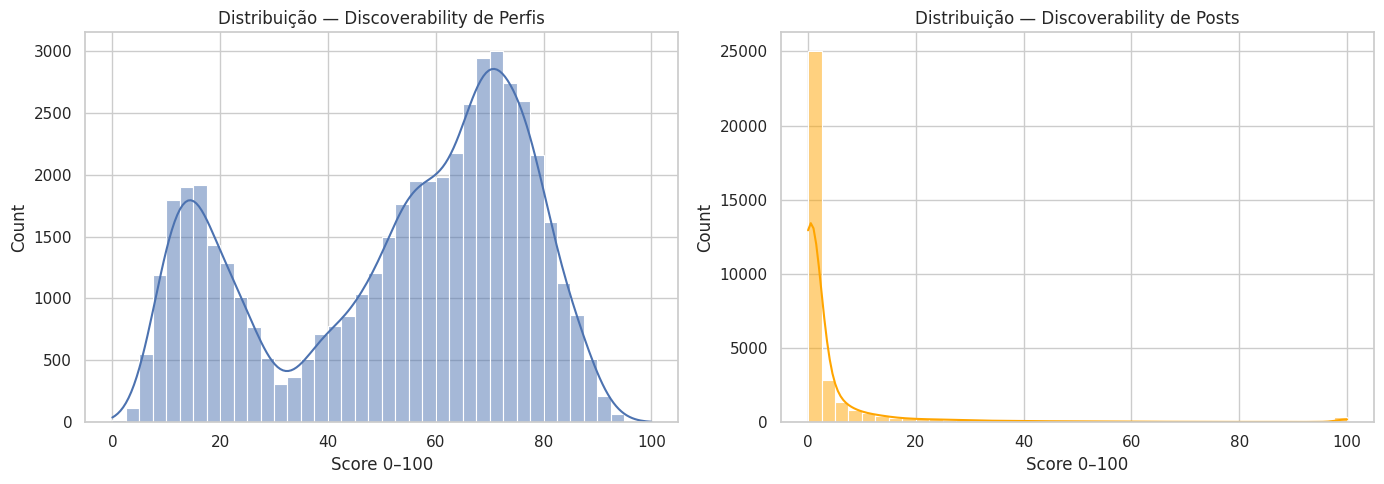

In [74]:
# ==============================
# 7. Análise exploratória rápida
# ==============================

# Distribuição dos targets.
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.histplot(df_profiles["profile_discoverability_score"], bins=40, kde=True, ax=axes[0])
axes[0].set_title("Distribuição — Discoverability de Perfis")
axes[0].set_xlabel("Score 0–100")

sns.histplot(df_posts["post_discoverability_score"], bins=40, kde=True, ax=axes[1], color="orange")
axes[1].set_title("Distribuição — Discoverability de Posts")
axes[1].set_xlabel("Score 0–100")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "target_distributions.png", dpi=150)
plt.show()


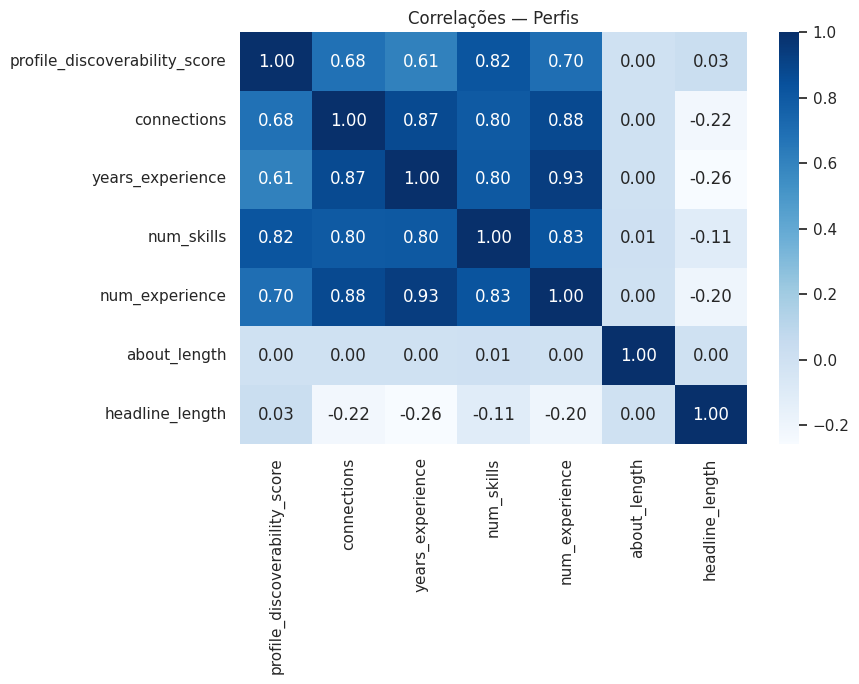

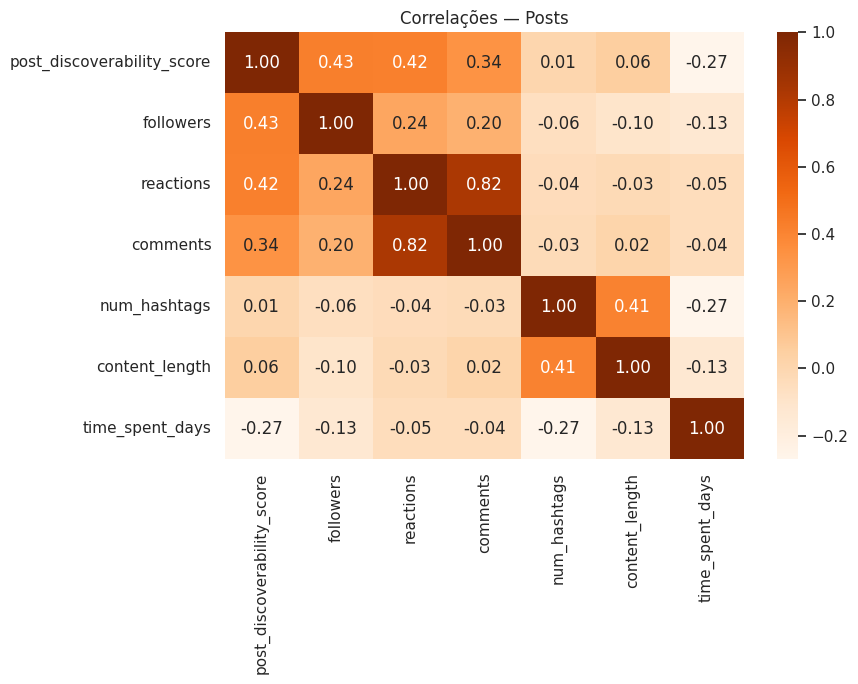

In [75]:
# ===================================
# 8. Correlações e grupos importantes
# ===================================

profile_corr_cols = [
    "profile_discoverability_score", "connections", "years_experience",
    "num_skills", "num_experience", "about_length", "headline_length",
]
profile_corr_cols = [c for c in profile_corr_cols if c in df_profiles.columns]

post_corr_cols = [
    "post_discoverability_score", "followers", "reactions", "comments",
    "num_hashtags", "content_length", "time_spent_days",
]
post_corr_cols = [c for c in post_corr_cols if c in df_posts.columns]

plt.figure(figsize=(9, 7))
sns.heatmap(df_profiles[profile_corr_cols].corr(numeric_only=True), annot=True, fmt=".2f", cmap="Blues")
plt.title("Correlações — Perfis")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "corr_profiles.png", dpi=150)
plt.show()

plt.figure(figsize=(9, 7))
sns.heatmap(df_posts[post_corr_cols].corr(numeric_only=True), annot=True, fmt=".2f", cmap="Oranges")
plt.title("Correlações — Posts")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "corr_posts.png", dpi=150)
plt.show()


In [76]:
# ========================================
# 9. Guardar datasets processados e schema
# ========================================

profiles_path = PROCESSED_DIR / "processed_profiles.pkl"
posts_path = PROCESSED_DIR / "processed_posts.pkl"

df_profiles.to_pickle(profiles_path)
df_posts.to_pickle(posts_path)

schema = {
    "profiles_shape": df_profiles.shape,
    "posts_shape": df_posts.shape,
    "profile_columns": df_profiles.columns.tolist(),
    "post_columns": df_posts.columns.tolist(),
    "targets": {
        "profiles": "profile_discoverability_score",
        "posts": "post_discoverability_score",
    },
    "note": "Targets são proxies académicos 0-100; não representam o algoritmo real do LinkedIn.",
}

with open(PROCESSED_DIR / "processed_schema.json", "w", encoding="utf-8") as f:
    json.dump(schema, f, ensure_ascii=False, indent=2)

print("Guardado:")
print("-", profiles_path)
print("-", posts_path)
print("-", PROCESSED_DIR / "processed_schema.json")


Guardado:
- /home/miguellaptop/Secretária/ML/data/processed/processed_profiles.pkl
- /home/miguellaptop/Secretária/ML/data/processed/processed_posts.pkl
- /home/miguellaptop/Secretária/ML/data/processed/processed_schema.json


## Conclusão do notebook 01

Neste ponto o projeto já tem dados processados, targets calculados e EDA inicial. O próximo notebook deve **criar features e fazer o split treino/validação/teste sem data leakage**.

Para posts, atenção especial no próximo notebook: `reactions`, `comments`, `time_spent`, `time_spent_days` e o próprio `post_discoverability_score` não devem entrar como features se o objetivo for prever a discoverability antes/no momento da publicação. Essas colunas são usadas para construir ou contextualizar o target.
